Preprocessing + Data Loading (Colab)

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
from zipfile import ZipFile

zip_path = "/content/drive/MyDrive/diabetic-retinopathy-dataset.zip"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/data')

print("Extraction done")

Extraction done


In [8]:
import os
print(os.listdir('/content/data'))

['Proliferate DR', 'Moderate DR', 'Severe DR', 'Healthy', 'Mild DR']


In [9]:
data_path = "/content/data"

In [10]:
import os

rename_map = {
    "Mild DR": "Mild",
    "Moderate DR": "Moderate",
    "Severe DR": "Severe",
    "Proliferate DR": "Proliferative"
}

for old, new in rename_map.items():
    old_path = os.path.join(data_path, old)
    new_path = os.path.join(data_path, new)
    if os.path.exists(old_path):
        os.rename(old_path, new_path)

print(os.listdir(data_path))

['Severe', 'Mild', 'Moderate', 'Proliferative', 'Healthy']


In [11]:
##Import Libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [12]:
##Create Data Generator
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1.0/255,
    validation_split=0.2
)

In [13]:
##Load Training Data
train_data = datagen.flow_from_directory(
    data_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

Found 2200 images belonging to 5 classes.


In [14]:
##Load Validation Data
val_data = datagen.flow_from_directory(
    data_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 550 images belonging to 5 classes.


In [15]:
print(train_data.class_indices)

{'Healthy': 0, 'Mild': 1, 'Moderate': 2, 'Proliferative': 3, 'Severe': 4}


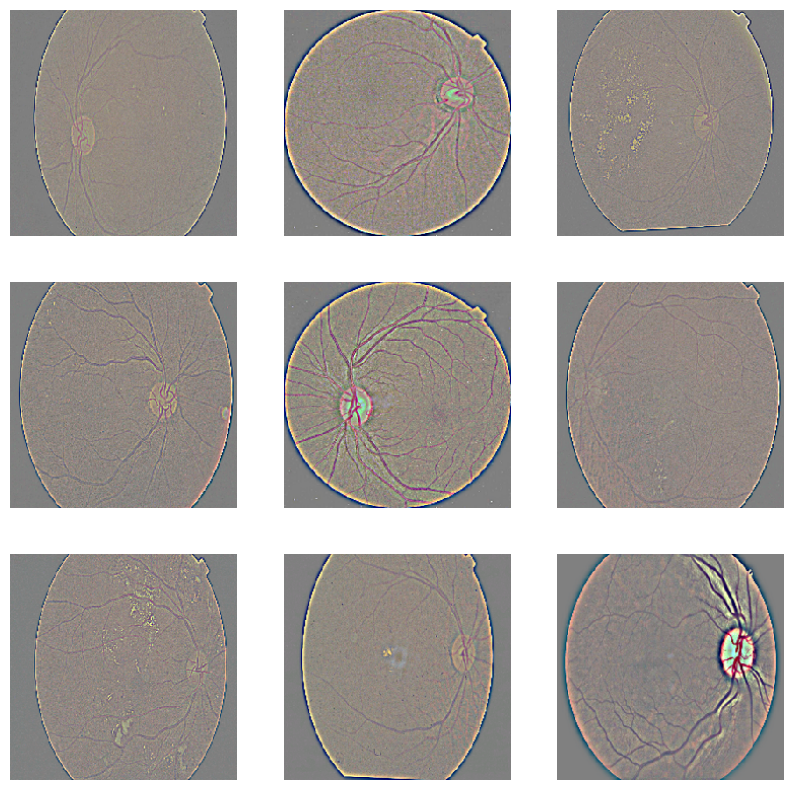

In [16]:
images, labels = next(train_data)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis('off')

plt.show()